# Lecture 7 · Diagnose overfitting and stop at the right checkpoint

**You will** predict which models underfit or overfit, calculate an early-stopping choice by hand, train a flexible model, and use validation—never test—to select the checkpoint.

> Rule for this notebook: **train updates parameters; validation chooses; test reports once.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
plt.rcParams.update({'figure.figsize': (7, 4), 'axes.grid': True})

## 1 · Make three sealed splits

We observe noisy samples from $y=\sin(2\pi x)$. Before running the cell, predict: which split may update coefficients, which split may choose degree/checkpoint, and which split should be touched only at the end?

In [2]:
def truth(x):
    return np.sin(2 * np.pi * x)

x = rng.uniform(0, 1, 72)
y = truth(x) + rng.normal(0, 0.22, len(x))
order = rng.permutation(len(x))
tr, va, te = order[:24], order[24:48], order[48:]
x_tr, y_tr = x[tr], y[tr]
x_va, y_va = x[va], y[va]
x_te, y_te = x[te], y[te]
print(f'train={len(tr)}, validation={len(va)}, test={len(te)}')

train=24, validation=24, test=24


## 2 · Capacity changes the shape

**Predict before running:**

- Which degree will have the largest training error?
- Which degree can bend around individual training samples?
- Is the smallest training error enough to choose the model?

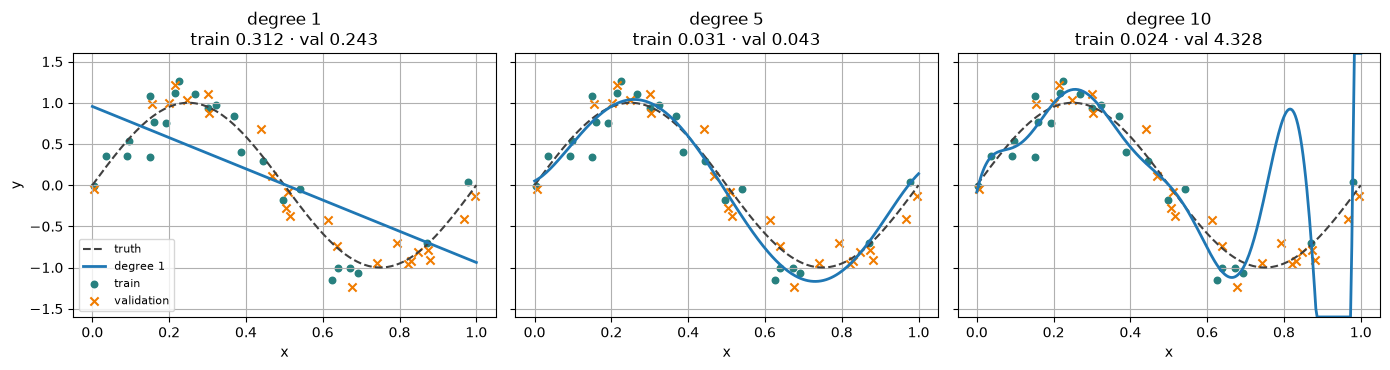

degree | train MSE | validation MSE
     1 |    0.3117 |         0.2425
     5 |    0.0308 |         0.0428
    10 |    0.0237 |         4.3282


In [3]:
grid = np.linspace(0, 1, 300)
degrees = [1, 5, 10]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True, sharey=True)
records = []
for ax, degree in zip(axes, degrees):
    coef = np.polyfit(x_tr, y_tr, degree)
    train_mse = np.mean((np.polyval(coef, x_tr) - y_tr) ** 2)
    val_mse = np.mean((np.polyval(coef, x_va) - y_va) ** 2)
    records.append((degree, train_mse, val_mse))
    ax.plot(grid, truth(grid), '--', color='0.25', label='truth')
    ax.plot(grid, np.clip(np.polyval(coef, grid), -1.6, 1.6), lw=2, label=f'degree {degree}')
    ax.scatter(x_tr, y_tr, s=22, color='#27807f', label='train')
    ax.scatter(x_va, y_va, s=35, marker='x', color='#f07c00', label='validation')
    ax.set_title(f'degree {degree}\ntrain {train_mse:.3f} · val {val_mse:.3f}')
    ax.set_ylim(-1.6, 1.6)
    ax.set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()
print('degree | train MSE | validation MSE')
for row in records:
    print(f'{row[0]:>6} | {row[1]:>9.4f} | {row[2]:>14.4f}')

**Explain:** Identify one plot as high bias and one as high variance. Cite both the curve shape and the two losses—not only the polynomial degree.

## 3 · Calculate the checkpoint before writing code

For validation losses $[1.25, 0.98, 0.82, 0.78, 0.84, 0.97]$, write down $t^\star=\arg\min_t L_{val}(t)$. Why is the last epoch wrong even though its training loss is smallest?

In [4]:
epochs_small = np.arange(1, 7)
train_small = np.array([1.20, 0.80, 0.45, 0.32, 0.28, 0.25])
val_small = np.array([1.25, 0.98, 0.82, 0.78, 0.84, 0.97])
best_small = int(np.argmin(val_small))
print(f'best checkpoint: epoch {epochs_small[best_small]} with val loss {val_small[best_small]:.2f}')
print(f'last checkpoint: epoch {epochs_small[-1]} with val loss {val_small[-1]:.2f}')

best checkpoint: epoch 4 with val loss 0.78
last checkpoint: epoch 6 with val loss 0.97


## 4 · Train, save the best checkpoint, and keep test sealed

We fit a degree-24 polynomial by gradient descent. The code stores a copy of the weights whenever validation improves. **Predict:** after the validation minimum, what directions should the two curves move if overfitting begins?

In [5]:
degree = 24
def raw_features(xx):
    return np.column_stack([xx ** k for k in range(degree + 1)])

P_tr, P_va = map(raw_features, (x_tr, x_va))
mu, sd = P_tr[:, 1:].mean(0), P_tr[:, 1:].std(0) + 1e-9
def standardize(P):
    Q = P.copy()
    Q[:, 1:] = (Q[:, 1:] - mu) / sd
    return Q
P_tr, P_va = map(standardize, (P_tr, P_va))

w = np.zeros(degree + 1)
best_w, best_epoch, best_val = w.copy(), None, np.inf
train_hist, val_hist = [], []
learning_rate = 0.02
epochs = np.arange(1, 6001)  # epoch 1 is the first parameter update
for epoch in epochs:
    gradient = P_tr.T @ (P_tr @ w - y_tr) / len(y_tr)
    w -= learning_rate * gradient
    train_loss = np.mean((P_tr @ w - y_tr) ** 2)
    val_loss = np.mean((P_va @ w - y_va) ** 2)
    train_hist.append(train_loss); val_hist.append(val_loss)
    if val_loss < best_val:
        best_val, best_epoch, best_w = val_loss, epoch, w.copy()

print(f'best epoch={best_epoch}, best val MSE={best_val:.4f}')
print(f'last val MSE={val_hist[-1]:.4f}')

best epoch=1640, best val MSE=0.1167
last val MSE=0.1756


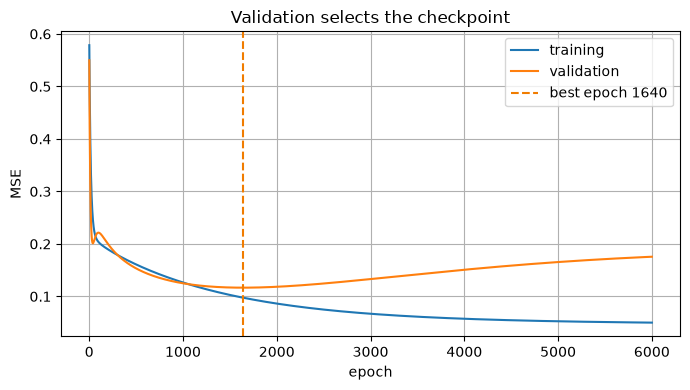

In [6]:
plt.plot(epochs, train_hist, label='training')
plt.plot(epochs, val_hist, label='validation')
plt.axvline(best_epoch, color='#f07c00', ls='--', label=f'best epoch {best_epoch}')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.title('Validation selects the checkpoint')
plt.legend(); plt.tight_layout(); plt.show()

## 5 · Test exactly once

The checkpoint and all choices are now fixed. Only now do we evaluate test.

In [7]:
P_te = standardize(raw_features(x_te))
best_test = np.mean((P_te @ best_w - y_te) ** 2)
print(f'frozen best-checkpoint test MSE = {best_test:.4f}')

frozen best-checkpoint test MSE = 0.1111


## Exit check

In two sentences, explain why (i) a small train–validation gap can still describe a bad model, and (ii) early stopping is a regularizer even though the architecture never changes.